# День 3 - Attention-матрицы

Цель: получить attention weights из DistilBERT и понять их форму.

In [1]:
import torch
import numpy as np

from transformers import AutoTokenizer, AutoModel

C:\ProgramData\anaconda3\envs\transformers_overall\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModel.from_pretrained(
    model_name,
    output_attentions=True
)

model.eval()

print("Model:", model_name)
print("Vocab size:", tokenizer.vocab_size)
print("Max length:", tokenizer.model_max_length)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4613.94it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: distilbert-base-uncased
Vocab size: 30522
Max length: 512


In [3]:
text = "The amazing movie won many awards"

tokens = tokenizer(text, return_tensors="pt")

print(tokens)

{'input_ids': tensor([[ 101, 1996, 6429, 3185, 2180, 2116, 2982,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}


In [4]:
token_list = tokenizer.convert_ids_to_tokens(tokens["input_ids"][0])

print(token_list)
print("Number of tokens:", len(token_list))

['[CLS]', 'the', 'amazing', 'movie', 'won', 'many', 'awards', '[SEP]']
Number of tokens: 8


In [5]:
with torch.no_grad():
    outputs = model(**tokens)

print(type(outputs))

print(outputs.keys())

<class 'transformers.modeling_outputs.BaseModelOutput'>
odict_keys(['last_hidden_state', 'attentions'])


In [6]:
print(type(outputs.attentions))
print("Количество слоев:", len(outputs.attentions))
print("Форма attention для слоя 0:", outputs.attentions[0].shape)

<class 'tuple'>
Количество слоев: 6
Форма attention для слоя 0: torch.Size([1, 12, 8, 8])


In [7]:
attention = outputs.attentions[0]

print("Attention layer 0 shape:", attention.shape)

attn_single = attention[0, 0]

print("Single head shape:", attn_single.shape)
print(attn_single)

Attention layer 0 shape: torch.Size([1, 12, 8, 8])
Single head shape: torch.Size([8, 8])
tensor([[0.0735, 0.1380, 0.0737, 0.0950, 0.1252, 0.0816, 0.0879, 0.3251],
        [0.3591, 0.1035, 0.0702, 0.0551, 0.1358, 0.0757, 0.0791, 0.1213],
        [0.3167, 0.0178, 0.0791, 0.0758, 0.1184, 0.0321, 0.1054, 0.2547],
        [0.1970, 0.0256, 0.1094, 0.0891, 0.1196, 0.0489, 0.2047, 0.2058],
        [0.4430, 0.0545, 0.0959, 0.1310, 0.0530, 0.0493, 0.0824, 0.0909],
        [0.4512, 0.0409, 0.0811, 0.0358, 0.1986, 0.0368, 0.0760, 0.0796],
        [0.4503, 0.0261, 0.0983, 0.1478, 0.0751, 0.0315, 0.0572, 0.1137],
        [0.2149, 0.1474, 0.0319, 0.0386, 0.0835, 0.1538, 0.0489, 0.2810]])


In [8]:
row_sums = attn_single.sum(dim=-1)

print(row_sums)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [9]:
print(token_list)
print("Количество слоев:", len(outputs.attentions))
print("Форма attention для слоя 0:", outputs.attentions[0].shape)
print("Single head shape:", attn_single.shape)
print(row_sums)

['[CLS]', 'the', 'amazing', 'movie', 'won', 'many', 'awards', '[SEP]']
Количество слоев: 6
Форма attention для слоя 0: torch.Size([1, 12, 8, 8])
Single head shape: torch.Size([8, 8])
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
attention_output_dir = Path("../outputs/attention")
attention_output_dir.mkdir(parents=True, exist_ok=True)

print("Папка для результатов:", attention_output_dir.resolve())

Папка для результатов: C:\Users\User\Projects\transformers_overall\outputs\attention


In [12]:
def visualize_attention(
    encoded_tokens,
    attentions,
    tokenizer,
    layer=0,
    head=0,
    output_dir=None,
    vmin=None,
    vmax=None,
    filename_suffix="",
):
    """
    Визуализирует attention для одной головы одного слоя.
    """

    num_layers = len(attentions)

    if not 0 <= layer < num_layers:
        raise ValueError(
            f"Слой {layer} недоступен. "
            f"Допустимые значения: 0–{num_layers - 1}"
        )

    layer_attention = attentions[layer]
    num_heads = layer_attention.shape[1]

    if not 0 <= head < num_heads:
        raise ValueError(
            f"Голова {head} недоступна. "
            f"Допустимые значения: 0–{num_heads - 1}"
        )

    # Первый текст батча, выбранная голова.
    attention_matrix = (
        layer_attention[0, head]
        .detach()
        .cpu()
        .numpy()
    )

    token_list = tokenizer.convert_ids_to_tokens(
        encoded_tokens["input_ids"][0]
    )

    expected_shape = (len(token_list), len(token_list))

    if attention_matrix.shape != expected_shape:
        raise ValueError(
            f"Матрица имеет форму {attention_matrix.shape}, "
            f"а ожидалась {expected_shape}"
        )

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        attention_matrix,
        xticklabels=token_list,
        yticklabels=token_list,
        cmap="viridis",
        cbar=True,
        square=True,
        vmin=vmin,
        vmax=vmax,
    )

    plt.title(f"Attention — layer {layer}, head {head}")
    plt.xlabel("Keys — на какие токены направлено внимание")
    plt.ylabel("Queries — какой токен смотрит")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        output_path = (
            output_dir
            / f"attention_layer{layer}_head{head}{filename_suffix}.png"
        )

        plt.savefig(
            output_path,
            dpi=150,
            bbox_inches="tight",
        )

        print("Изображение сохранено:", output_path.resolve())

    plt.show()
    plt.close()

Общая шкала: 0.000 — 0.952
Изображение сохранено: C:\Users\User\Projects\transformers_overall\outputs\attention\attention_layer0_head0_common_scale.png


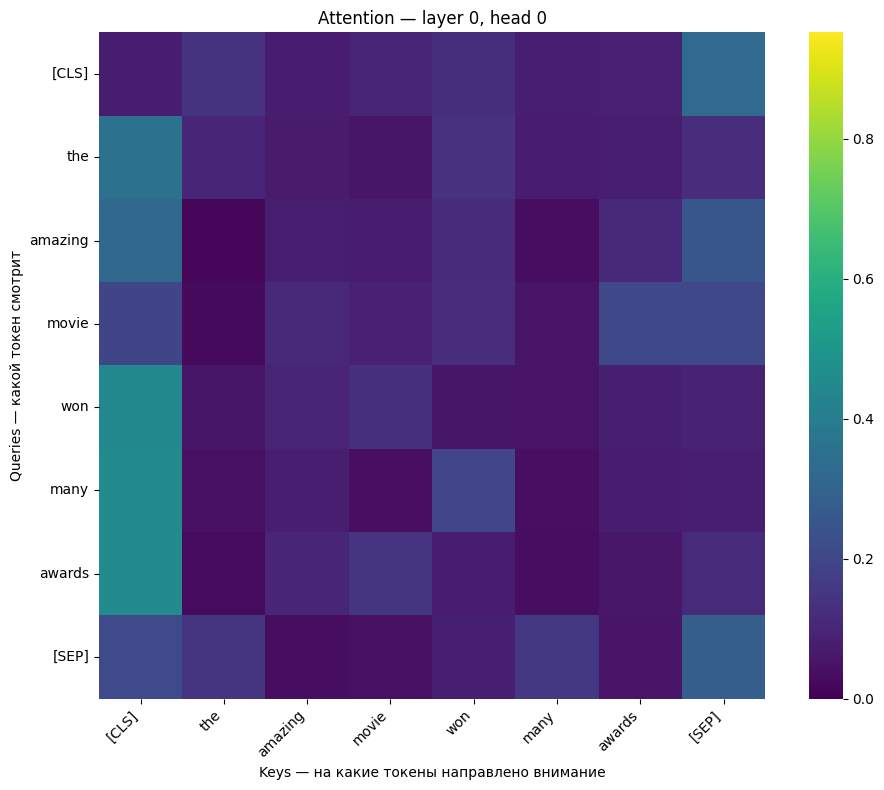

Изображение сохранено: C:\Users\User\Projects\transformers_overall\outputs\attention\attention_layer3_head0_common_scale.png


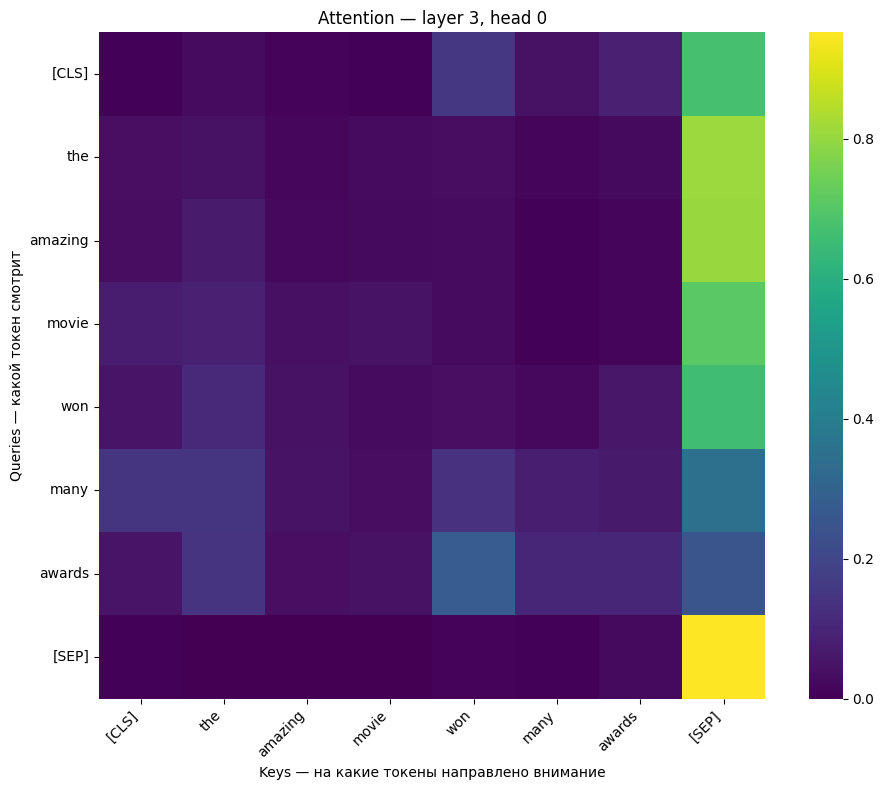

Изображение сохранено: C:\Users\User\Projects\transformers_overall\outputs\attention\attention_layer5_head0_common_scale.png


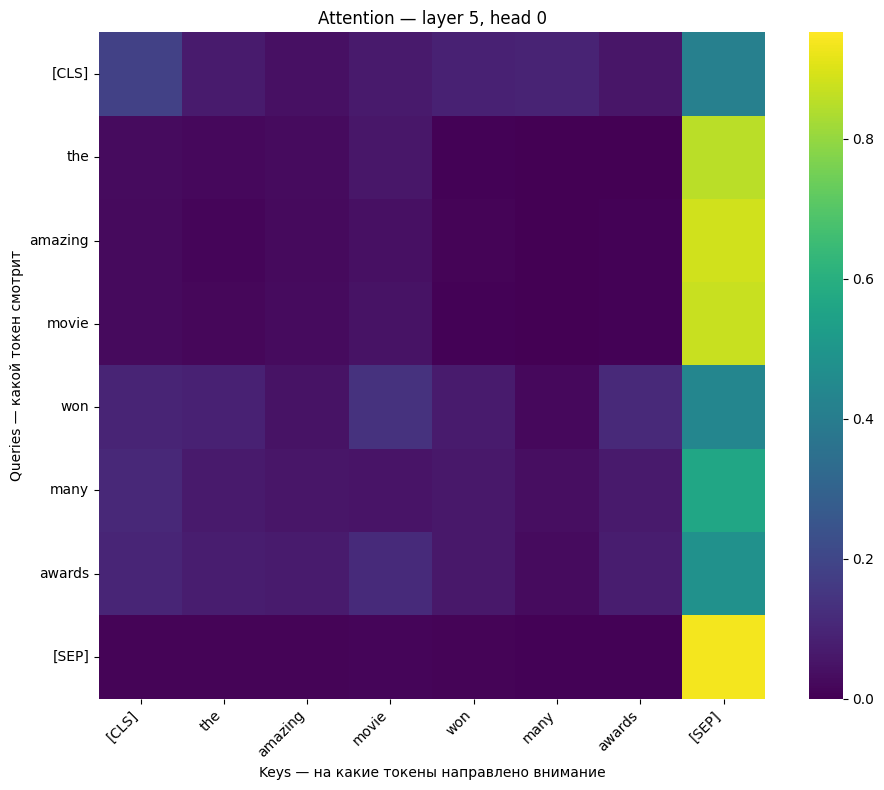

In [13]:
layers_to_compare = [0, 3, 5]
head_to_compare = 0

selected_matrices = [
    outputs.attentions[layer][0, head_to_compare]
    for layer in layers_to_compare
]

common_vmin = 0.0
common_vmax = max(
    matrix.max().item()
    for matrix in selected_matrices
)

print(
    f"Общая шкала: "
    f"{common_vmin:.3f} — {common_vmax:.3f}"
)

for layer in layers_to_compare:
    visualize_attention(
        encoded_tokens=tokens,
        attentions=outputs.attentions,
        tokenizer=tokenizer,
        layer=layer,
        head=head_to_compare,
        output_dir=attention_output_dir,
        vmin=common_vmin,
        vmax=common_vmax,
        filename_suffix="_common_scale",
    )

In [14]:
def visualize_mean_attention(
    encoded_tokens,
    attentions,
    tokenizer,
    layer=0,
    output_dir=None,
    vmin=0.0,
    vmax=None,
):
    """
    Усредняет attention по всем головам выбранного слоя.
    """

    num_layers = len(attentions)

    if not 0 <= layer < num_layers:
        raise ValueError(
            f"Слой {layer} недоступен. "
            f"Допустимые значения: 0–{num_layers - 1}"
        )

    # Форма до усреднения:
    # [num_heads, seq_len, seq_len]
    layer_attention = attentions[layer][0]

    # Усредняем по измерению голов.
    # Результат: [seq_len, seq_len]
    mean_attention = (
        layer_attention
        .mean(dim=0)
        .detach()
        .cpu()
        .numpy()
    )

    token_list = tokenizer.convert_ids_to_tokens(
        encoded_tokens["input_ids"][0]
    )

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        mean_attention,
        xticklabels=token_list,
        yticklabels=token_list,
        cmap="viridis",
        cbar=True,
        square=True,
        vmin=vmin,
        vmax=vmax,
    )

    plt.title(
        f"Mean attention across all heads — layer {layer}"
    )
    plt.xlabel("Keys — на какие токены направлено внимание")
    plt.ylabel("Queries — какой токен смотрит")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        output_path = (
            output_dir
            / f"attention_layer{layer}_mean_heads.png"
        )

        plt.savefig(
            output_path,
            dpi=150,
            bbox_inches="tight",
        )

        print("Изображение сохранено:", output_path.resolve())

    plt.show()
    plt.close()

Изображение сохранено: C:\Users\User\Projects\transformers_overall\outputs\attention\attention_layer5_mean_heads.png


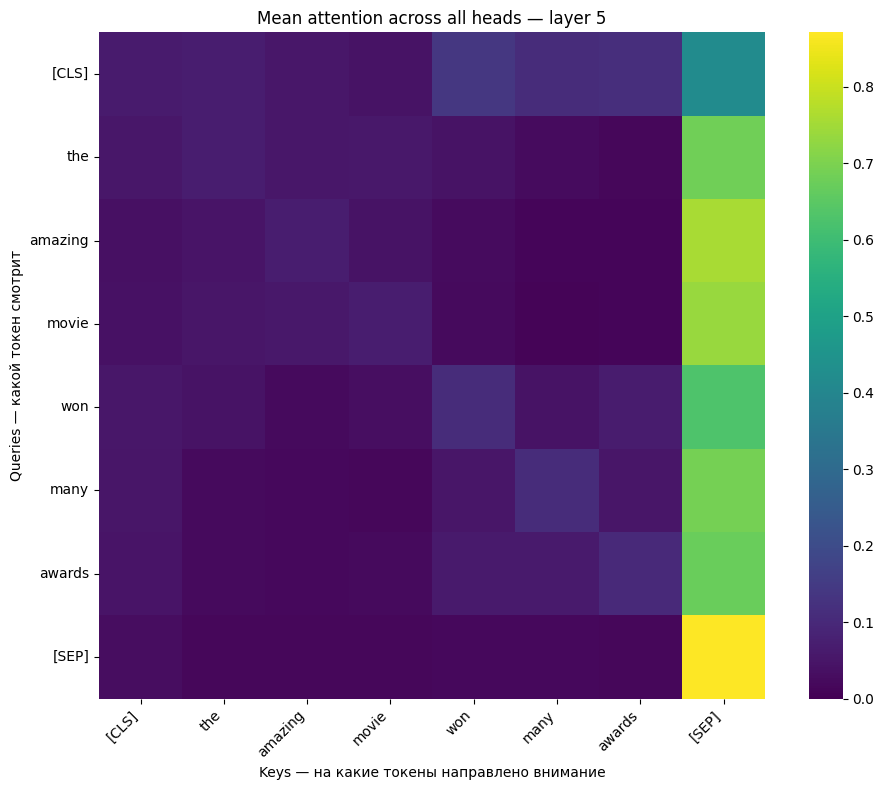

In [15]:
visualize_mean_attention(
    encoded_tokens=tokens,
    attentions=outputs.attentions,
    tokenizer=tokenizer,
    layer=5,
    output_dir=attention_output_dir,
)

Общая шкала для голов: 0.000 — 0.962
Изображение сохранено: C:\Users\User\Projects\transformers_overall\outputs\attention\attention_layer5_head0_heads_comparison.png


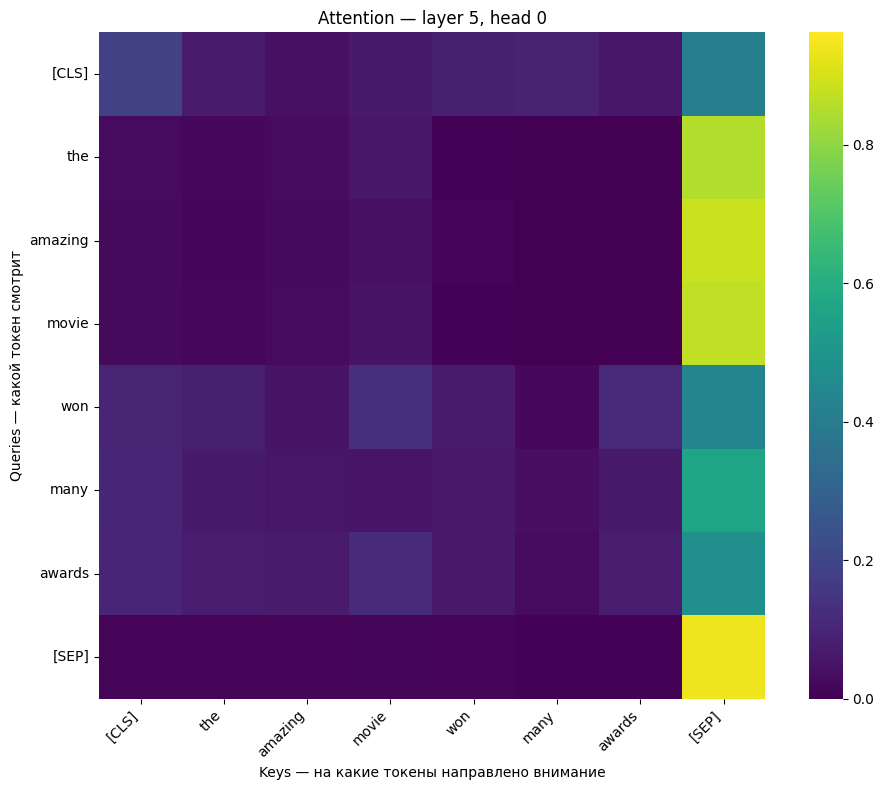

Изображение сохранено: C:\Users\User\Projects\transformers_overall\outputs\attention\attention_layer5_head3_heads_comparison.png


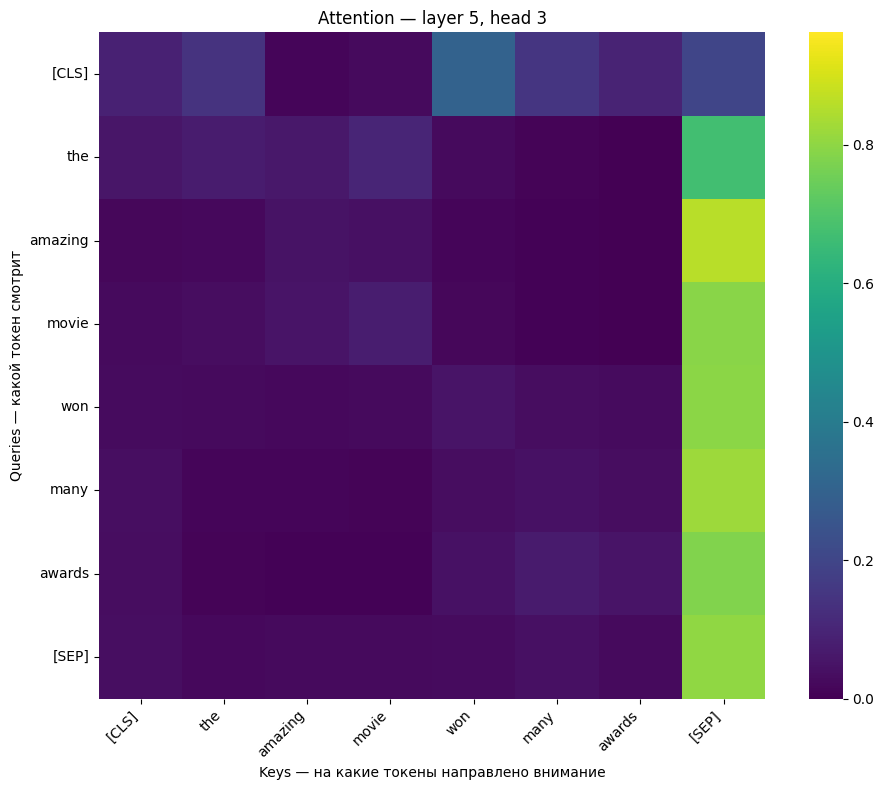

Изображение сохранено: C:\Users\User\Projects\transformers_overall\outputs\attention\attention_layer5_head6_heads_comparison.png


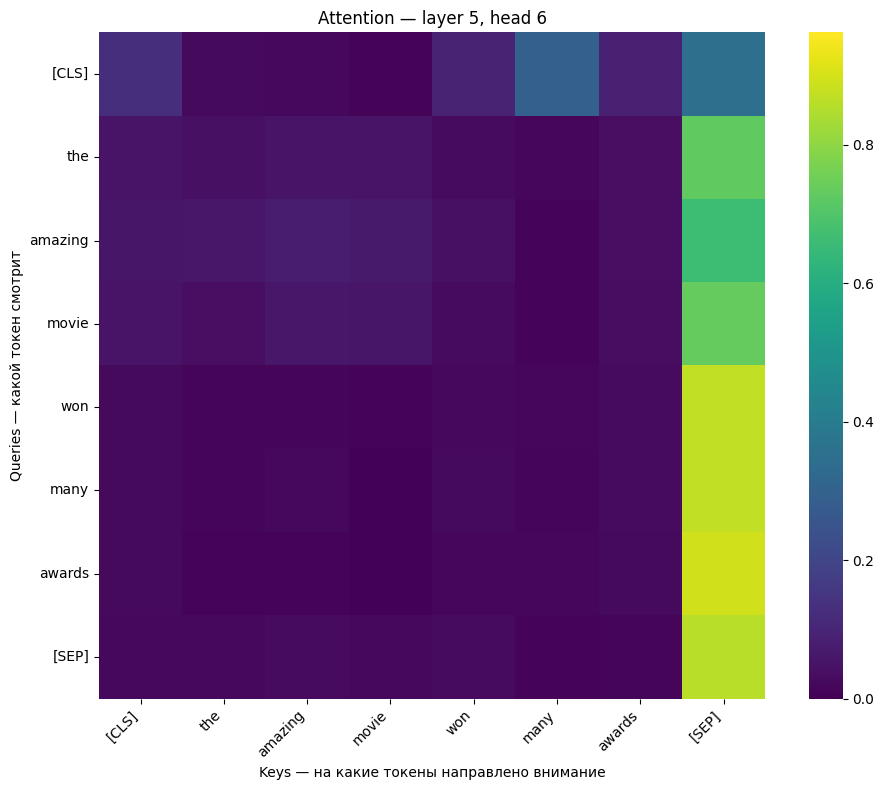

Изображение сохранено: C:\Users\User\Projects\transformers_overall\outputs\attention\attention_layer5_head9_heads_comparison.png


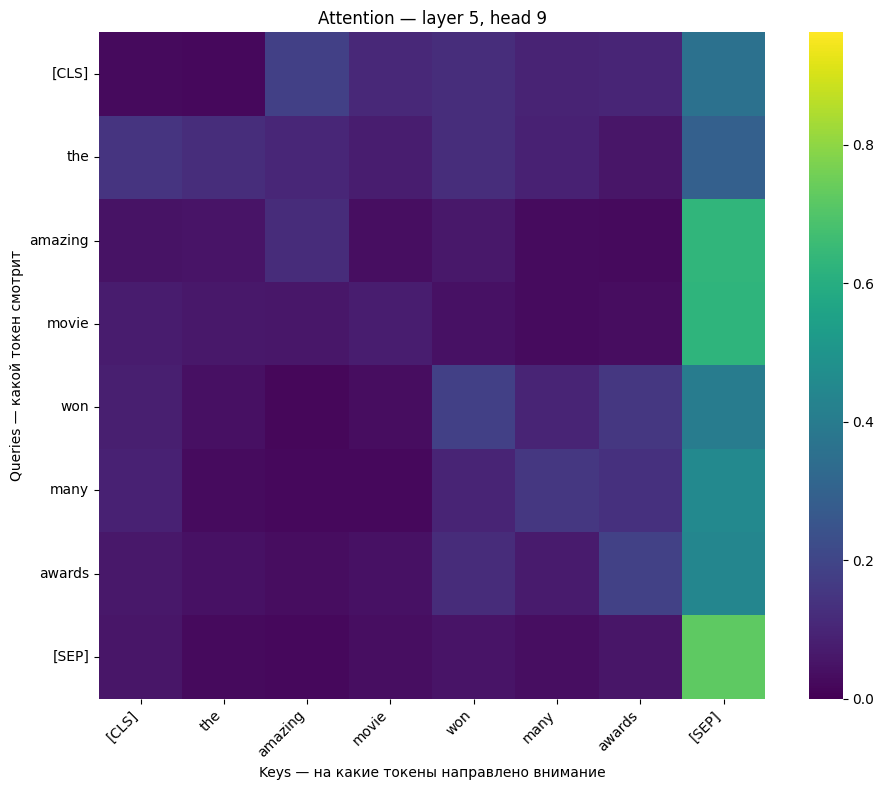

Изображение сохранено: C:\Users\User\Projects\transformers_overall\outputs\attention\attention_layer5_head11_heads_comparison.png


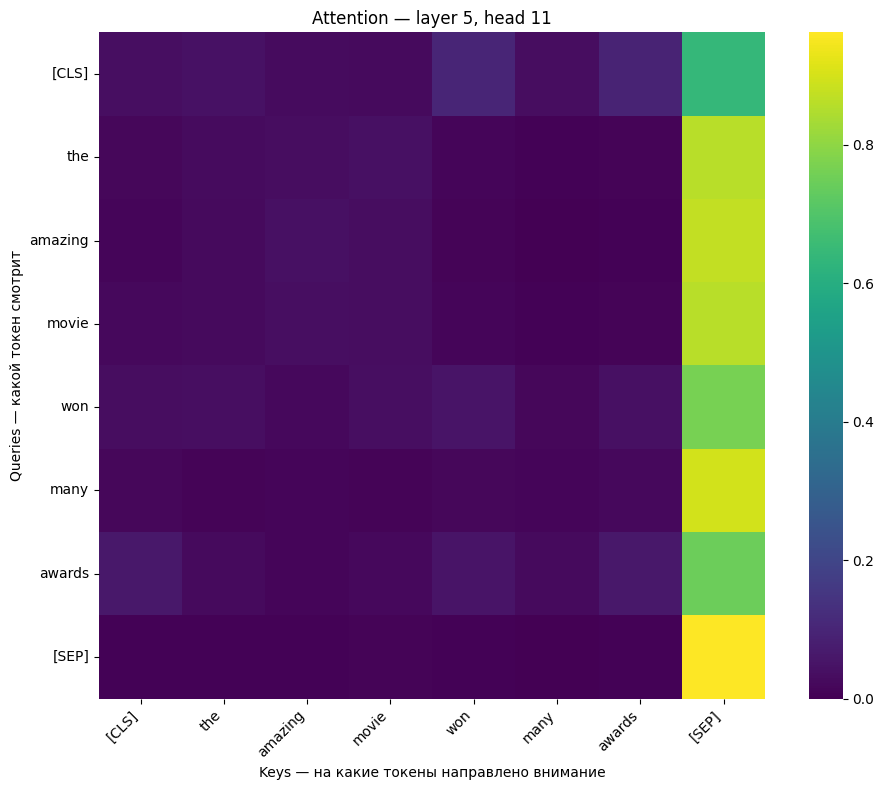

In [16]:
layer_to_compare = 5
heads_to_compare = [0, 3, 6, 9, 11]

selected_head_matrices = [
    outputs.attentions[layer_to_compare][0, head]
    for head in heads_to_compare
]

heads_common_vmin = 0.0
heads_common_vmax = max(
    matrix.max().item()
    for matrix in selected_head_matrices
)

print(
    f"Общая шкала для голов: "
    f"{heads_common_vmin:.3f} — {heads_common_vmax:.3f}"
)

for head in heads_to_compare:
    visualize_attention(
        encoded_tokens=tokens,
        attentions=outputs.attentions,
        tokenizer=tokenizer,
        layer=layer_to_compare,
        head=head,
        output_dir=attention_output_dir,
        vmin=heads_common_vmin,
        vmax=heads_common_vmax,
        filename_suffix="_heads_comparison",
    )

In [17]:
sentiment_text = (
    "This movie was absolutely terrible and I hated it"
)

sentiment_tokens = tokenizer(
    sentiment_text,
    return_tensors="pt",
)

with torch.no_grad():
    sentiment_outputs = model(**sentiment_tokens)

sentiment_token_list = tokenizer.convert_ids_to_tokens(
    sentiment_tokens["input_ids"][0]
)

print(sentiment_token_list)

['[CLS]', 'this', 'movie', 'was', 'absolutely', 'terrible', 'and', 'i', 'hated', 'it', '[SEP]']


Изображение сохранено: C:\Users\User\Projects\transformers_overall\outputs\attention\attention_layer5_mean_heads.png


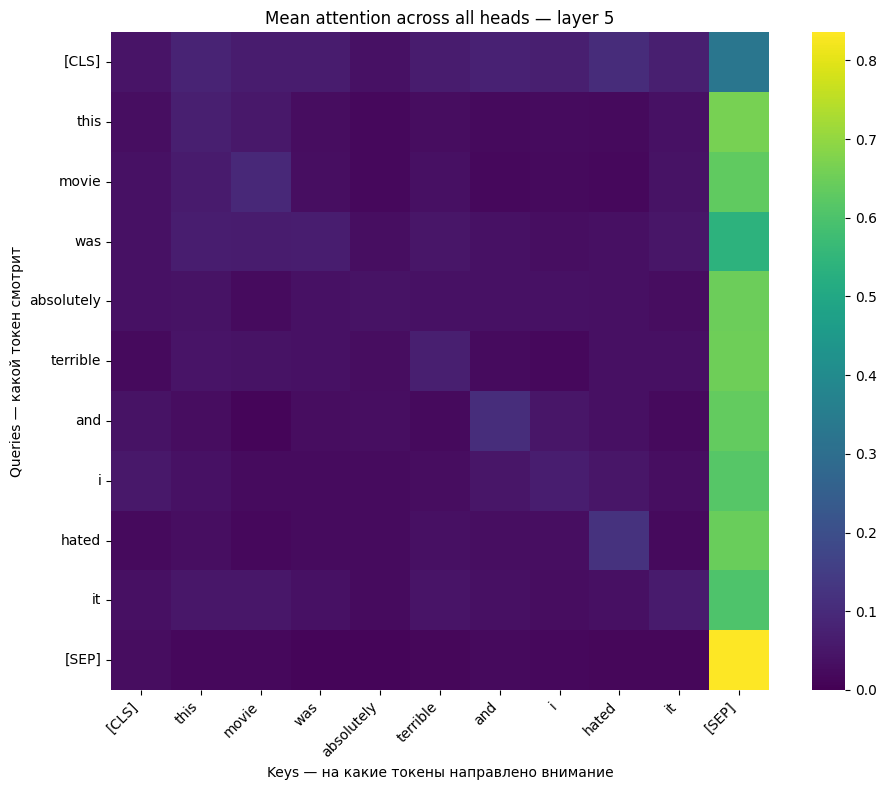

In [18]:
visualize_mean_attention(
    encoded_tokens=sentiment_tokens,
    attentions=sentiment_outputs.attentions,
    tokenizer=tokenizer,
    layer=5,
    output_dir=attention_output_dir,
)

In [19]:
terrible_index = sentiment_token_list.index("terrible")

last_layer_attention = sentiment_outputs.attentions[5][0]

# Усреднение 12 голов
mean_last_layer_attention = last_layer_attention.mean(dim=0)

terrible_attention_row = mean_last_layer_attention[terrible_index]

top_k = min(5, len(sentiment_token_list))
top_values, top_indices = torch.topk(
    terrible_attention_row,
    k=top_k,
)

print("Токен terrible смотрит на:")

for value, index in zip(top_values, top_indices):
    token = sentiment_token_list[index.item()]
    print(f"{token:15} {value.item():.4f}")

Токен terrible смотрит на:
[SEP]           0.6509
terrible        0.0692
this            0.0442
movie           0.0406
was             0.0366


In [20]:
terrible_attention_column = mean_last_layer_attention[
    :,
    terrible_index,
]

top_values, top_indices = torch.topk(
    terrible_attention_column,
    k=top_k,
)

print("На токен terrible смотрят:")

for value, index in zip(top_values, top_indices):
    token = sentiment_token_list[index.item()]
    print(f"{token:15} {value.item():.4f}")

На токен terrible смотрят:
terrible        0.0692
[CLS]           0.0627
was             0.0479
it              0.0433
absolutely      0.0368


## Выводы

- DistilBERT содержит 6 трансформерных слоёв и 12 attention-голов.
- Attention одного слоя имеет форму
  `[batch_size, num_heads, seq_len, seq_len]`.
- Каждая строка attention-матрицы после softmax суммируется до 1.
- Разные головы одного слоя демонстрируют разные паттерны внимания.
- Некоторые головы могут специализироваться на `[CLS]` и `[SEP]`.
- Нельзя интерпретировать одну голову как полное объяснение работы модели.
- Усреднение по головам помогает увидеть общую тенденцию слоя, но скрывает специализацию отдельных голов.
- Для корректного визуального сравнения графиков использовалась единая цветовая шкала.
- Attention weights показывают внутренние связи модели, но сами по себе не являются полным объяснением её решения.